**Problem Statement**

The organization is experiencing a noticeable increase in employee attrition, which is leading to:

· Increased hiring and onboarding costs

· Loss of experienced workforce

· Reduced productivity and team stability

· Impact on overall business performance

Currently, there is no proactive mechanism to identify employees who are likely to leave the organization.

The objective is to build a predictive system that can identify employees at risk of attrition and provide actionable insights to the Human Resources (HR) team for timely intervention.

In [110]:
import pandas as pd

In [111]:
df = pd.read_csv('/content/HR-Employee-Attrition.csv')
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [112]:
df.shape

(1470, 35)

In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [114]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [115]:
df.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [116]:
df.tail(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [117]:
df.count()

,0
Age,1470
Attrition,1470
BusinessTravel,1470
DailyRate,1470
Department,1470
DistanceFromHome,1470
Education,1470
EducationField,1470
EmployeeCount,1470
EmployeeNumber,1470


In [118]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [119]:
print(len(df.columns))

35


In [120]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [121]:
df.duplicated().sum()

np.int64(0)

In [122]:
categorical_columns = df.select_dtypes(include='object').columns
categorical_columns

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

In [123]:
numrical_columns = df.select_dtypes(exclude='object').columns
numrical_columns

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [124]:
# outlier
from numpy._core.defchararray import lower
## Outlier handling

for col in numrical_columns:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3-Q1

  LB = Q1 - 1.5*IQR
  UB = Q3 + 1.5*IQR

  ## Filter outliers

  df = df[(df[col]>= LB) & (df[col]<= UB)]

In [125]:
df.shape

(699, 35)

In [126]:
categorical_data = df.select_dtypes(include='object')
categorical_data

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Y,Yes
3,No,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Y,Yes
5,No,Travel_Frequently,Research & Development,Life Sciences,Male,Laboratory Technician,Single,Y,No
11,No,Travel_Rarely,Research & Development,Life Sciences,Female,Laboratory Technician,Single,Y,Yes
12,No,Travel_Rarely,Research & Development,Life Sciences,Male,Research Scientist,Divorced,Y,No
...,...,...,...,...,...,...,...,...,...
1463,No,Non-Travel,Research & Development,Medical,Male,Manufacturing Director,Single,Y,No
1464,No,Travel_Rarely,Sales,Other,Female,Sales Representative,Single,Y,No
1465,No,Travel_Frequently,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
1468,No,Travel_Frequently,Sales,Medical,Male,Sales Executive,Married,Y,No


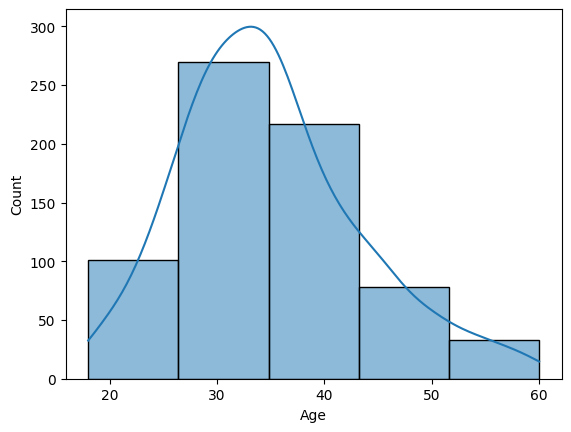

In [127]:
### Univariate analysis
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df['Age'], kde= True, bins = 5)
plt.show()

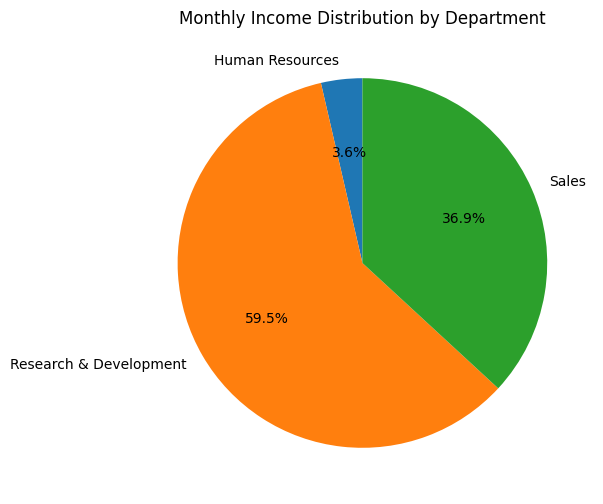

In [128]:
# Group by Department to get total income per department
income_by_dept = df.groupby('Department')['MonthlyIncome'].sum()

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(income_by_dept, labels=income_by_dept.index, autopct='%1.1f%%', startangle=90)
plt.title("Monthly Income Distribution by Department")
plt.show()

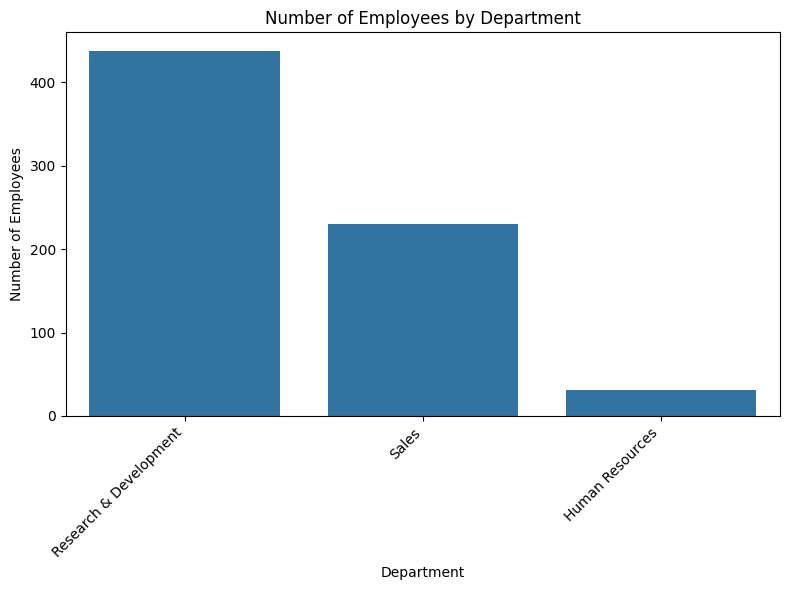

In [129]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Department')
plt.title('Number of Employees by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Monthly Income')

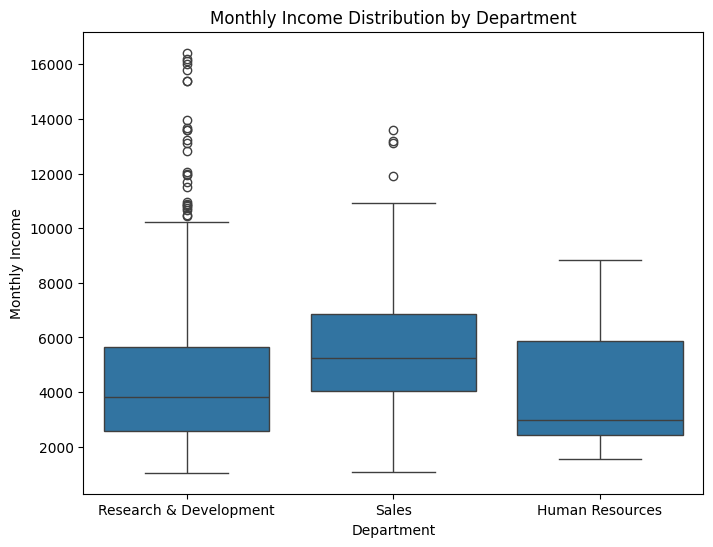

In [130]:
# Bivariate Analysis
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Department', y='MonthlyIncome')
plt.title('Monthly Income Distribution by Department')
plt.xlabel('Department')
plt.ylabel('Monthly Income')

In [131]:
numric = df.select_dtypes(exclude='object')
numric

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
2,37,1373,2,2,1,4,4,92,2,1,...,2,80,0,7,3,3,0,0,0,0
3,33,1392,3,4,1,5,4,56,3,1,...,3,80,0,8,3,3,8,7,3,0
5,32,1005,2,2,1,8,4,79,3,1,...,3,80,0,8,2,2,7,7,3,6
11,29,153,15,2,1,15,4,49,2,2,...,4,80,0,10,3,3,9,5,0,8
12,31,670,26,1,1,16,1,31,3,1,...,4,80,1,5,1,2,5,2,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1463,31,325,5,3,1,2057,2,74,3,2,...,2,80,0,10,2,3,9,4,1,7
1464,26,1167,5,3,1,2060,4,30,2,1,...,4,80,0,5,2,3,4,2,0,0
1465,36,884,23,2,1,2061,3,41,4,2,...,3,80,1,17,3,3,5,2,0,3
1468,49,1023,2,3,1,2065,4,63,2,2,...,4,80,0,17,3,2,9,6,0,8


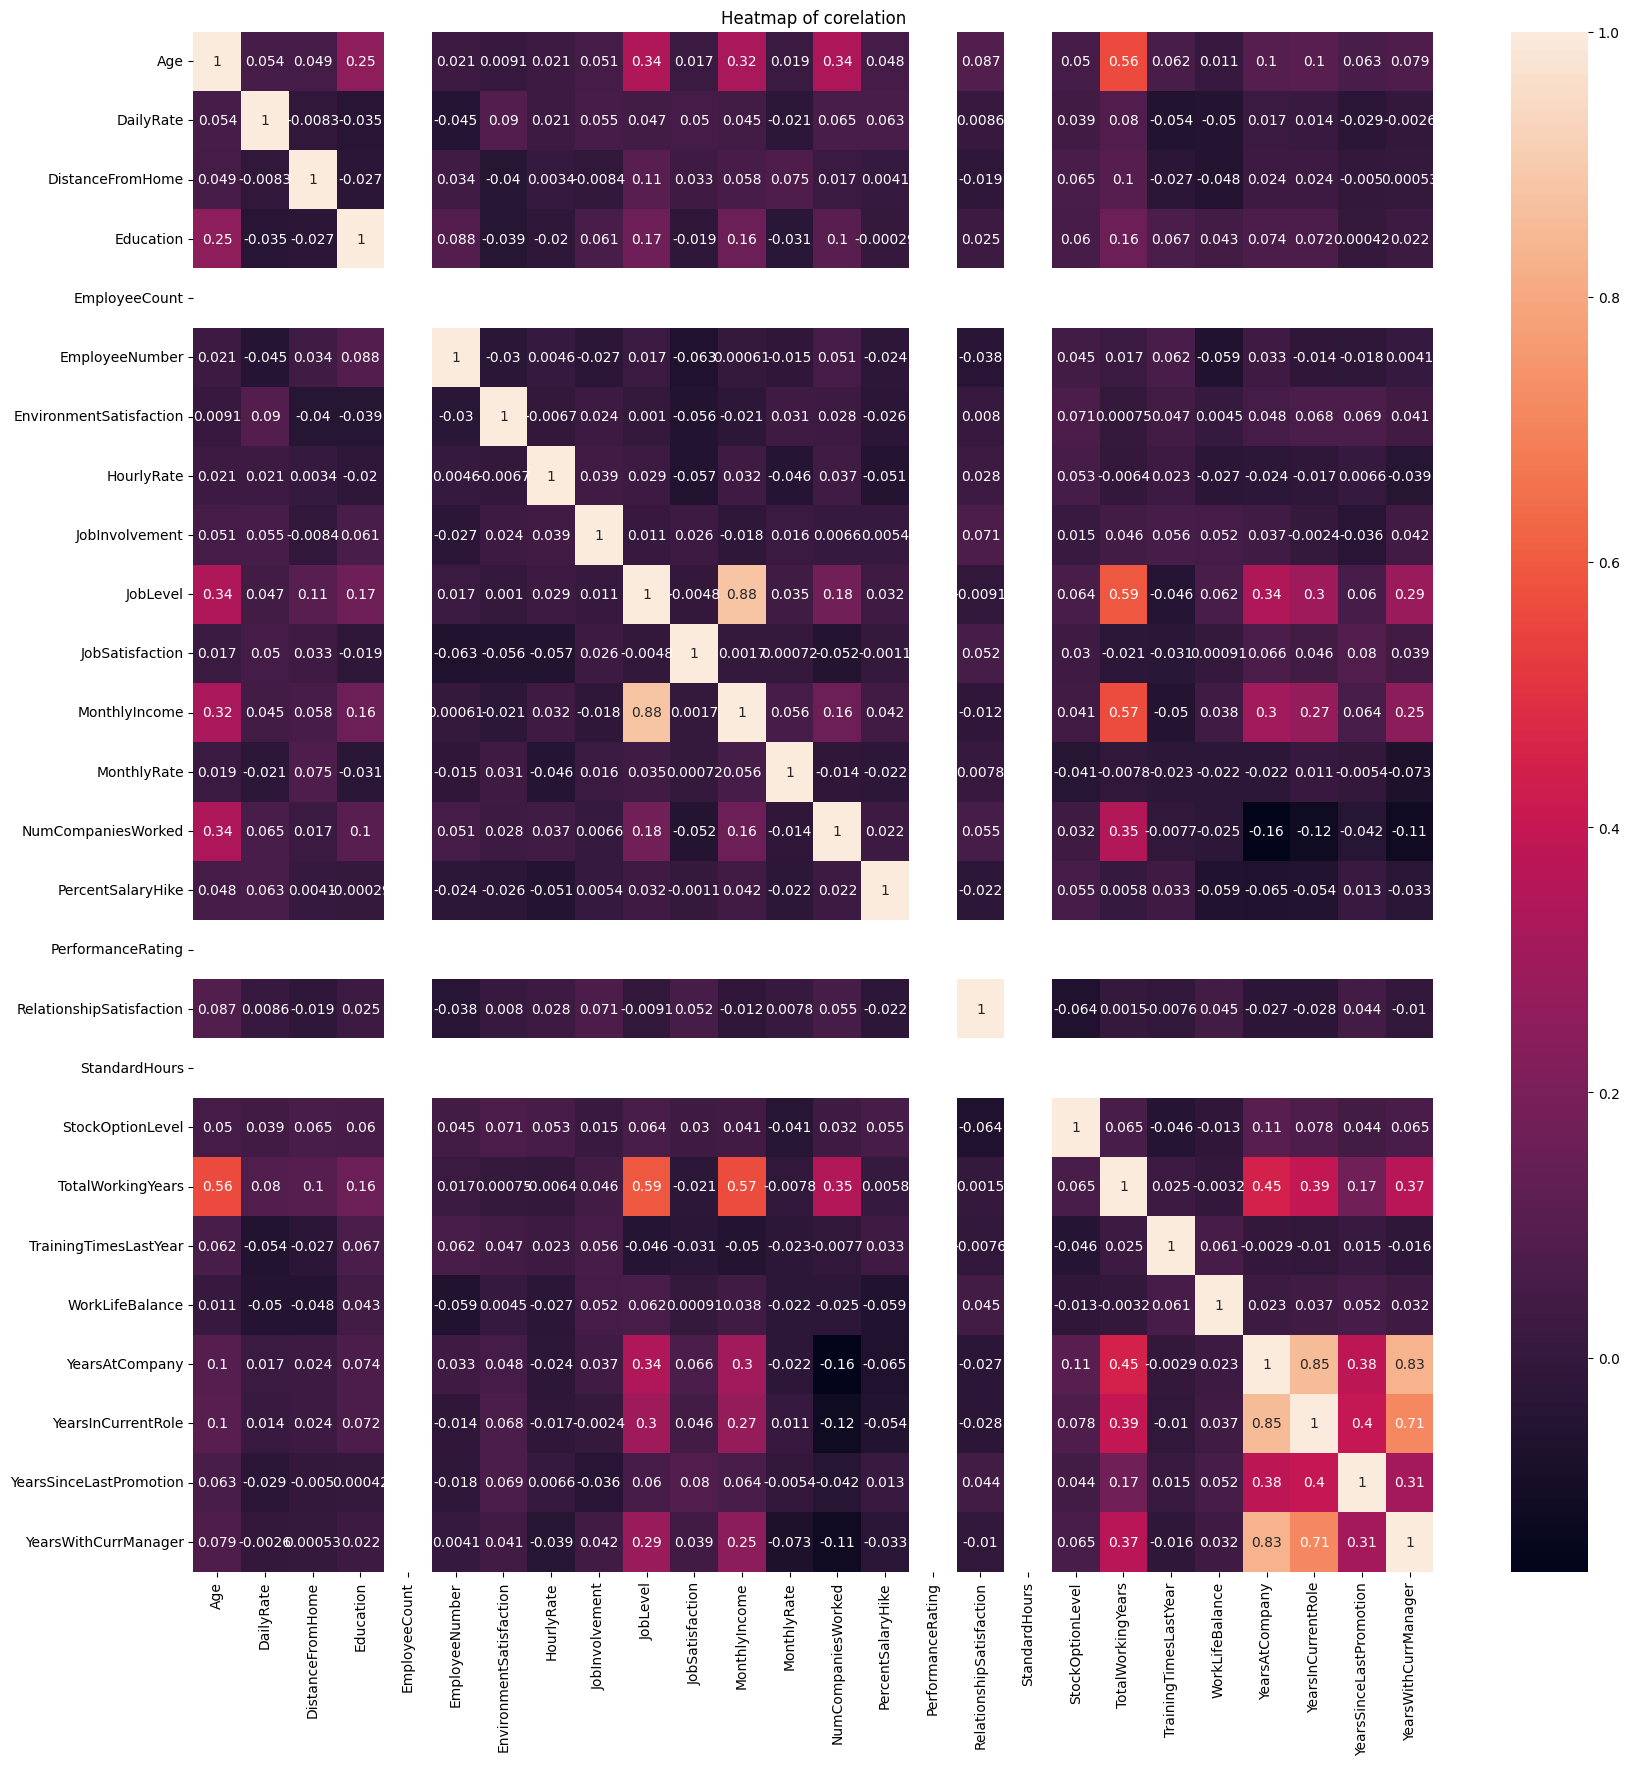

In [132]:
figer_size = (20, 20)
plt.figure(figsize=figer_size)
sns.heatmap(numric.corr(), annot=True)
plt.title('Heatmap of corelation')
plt.show()

Convert Cat Data To Numric Data

In [133]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder

In [134]:
for col in categorical_data:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])


In [135]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
2,37,1,2,1373,1,2,2,4,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,1,5,...,3,80,0,8,3,3,8,7,3,0
5,32,0,1,1005,1,2,2,1,1,8,...,3,80,0,8,2,2,7,7,3,6
11,29,0,2,153,1,15,2,1,1,15,...,4,80,0,10,3,3,9,5,0,8
12,31,0,2,670,1,26,1,1,1,16,...,4,80,1,5,1,2,5,2,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1463,31,0,0,325,1,5,3,3,1,2057,...,2,80,0,10,2,3,9,4,1,7
1464,26,0,2,1167,2,5,3,4,1,2060,...,4,80,0,5,2,3,4,2,0,0
1465,36,0,1,884,1,23,2,3,1,2061,...,3,80,1,17,3,3,5,2,0,3
1468,49,0,1,1023,2,2,3,3,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [136]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split

In [137]:
# Model Bulding
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [138]:
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size =0.8)

In [139]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((559, 34), (140, 34), (559,), (140,))

In [140]:
# a. Model initialization
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

In [141]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()  ## storing the model in an alias name

In [142]:
# b. Model training (MOST IMPORTANT)
lr.fit(X_train, y_train) ## Takes the X_train, y_train. Applied OLS method to get the best fit line

LinearRegression()

In [143]:
## c. Extract model parameters
lr.intercept_

np.float64(0.8995472786728386)

In [144]:
lr.coef_

array([-5.30806883e-03, -4.21016243e-03, -7.05554942e-06,  9.83916059e-02,
        3.19681450e-03,  2.20400098e-02,  2.34892968e-03,  4.16875735e-17,
       -1.27069342e-05, -4.21529184e-02,  5.02351275e-02,  4.74761651e-04,
       -6.55701645e-02, -8.79575509e-03, -1.06808195e-02, -4.92176120e-02,
        3.43260925e-02, -9.33612960e-06,  2.21509583e-06,  1.85672051e-02,
       -6.93889390e-17,  1.85211826e-01, -1.26060202e-02, -1.38777878e-17,
       -2.15616959e-02, -2.77555756e-17, -6.74586622e-02, -7.02630816e-03,
        2.75182869e-02, -4.49946008e-02, -1.55281560e-03, -1.23132546e-02,
        4.83465364e-03,  5.13327646e-05])

In [151]:
## equation of line is y = 0.046x + 7.102
output = lr.predict([[100]])
output

ValueError: X has 1 features, but LinearRegression is expecting 34 features as input.

In [145]:
## d. Model evalauation

y_pred = lr.predict(X_test)

In [146]:
y_pred.shape

(140,)

In [147]:
## e. Comparison of metrics

from sklearn import metrics

In [148]:
print("MAE: ", metrics.mean_absolute_error(y_test, y_pred))
print("MSE: ", metrics.mean_squared_error(y_test, y_pred))
print("R2 score: ", metrics.r2_score(y_pred, y_test))

MAE:  0.25121027433844667
MSE:  0.10811823119485214
R2 score:  -1.8914707486949718


In [152]:
from sklearn.linear_model import LogisticRegression

# Model initialization
log_reg = LogisticRegression()

# Model training
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)

# Probability outputs
y_prob = log_reg.predict_proba(X_test)

# Model evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8357142857142857
Confusion Matrix:
 [[115   0]
 [ 23   2]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      1.00      0.91       115
           1       1.00      0.08      0.15        25

    accuracy                           0.84       140
   macro avg       0.92      0.54      0.53       140
weighted avg       0.86      0.84      0.77       140



6. Visualization

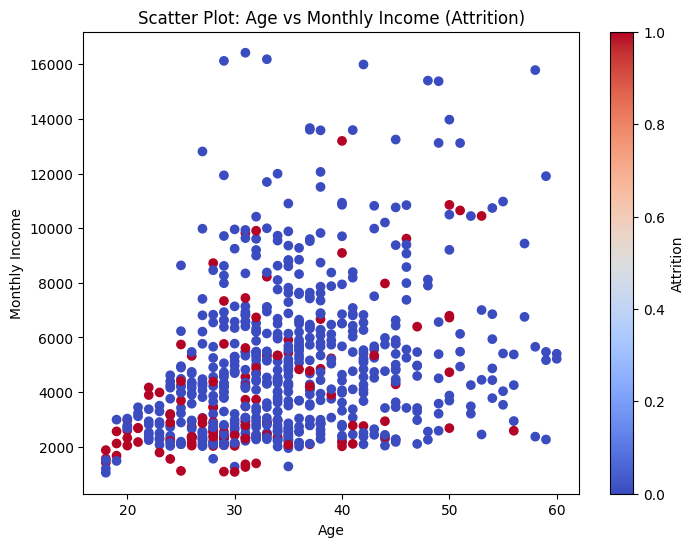

In [154]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df['Age'], df['MonthlyIncome'], c=df['Attrition'], cmap='coolwarm')
plt.xlabel("Age")
plt.ylabel("Monthly Income")
plt.title("Scatter Plot: Age vs Monthly Income (Attrition)")
plt.colorbar(label="Attrition")
plt.show()